In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.research.qcut_analyzer import QcutAnalyzer
# QcutAnalyzer.plot_qcut_analysis(df, col_a='Factor_A', col_b='Return')
from sdk_core import configure
from sdk_core import TwMarketData
# configure()
from src.research.rolling_model import train_and_predict_ridge_rolling

tw = TwMarketData()
# 取得還原股價
df = tw.get_security_price_adjusted("2025-12-31", "2330")

import os
import numpy as np
from tqdm import tqdm
import time
import datetime
import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
# 將最大顯示欄位數量設為 None（代表無上限）
pd.set_option('display.max_columns', None)

import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))

import pyarrow as pa
schema = pa.schema([
    ('price', pa.decimal128(10, 4)), 
    # 其他欄位如果沒特別指定，pyarrow 會自動推斷
])

from backTest import BackTest
from factorAnalyzer import FactorAnalyzer_Polars


/home/kevin/Project/HFT/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

folder_path = './data'  # 資料夾路徑
files = os.listdir(folder_path)

# 過濾掉資料夾，只留下檔案
file_names = np.array([f for f in files if os.path.isfile(os.path.join(folder_path, f))])
file_names.sort()
print(file_names[-5:])

['20260407.parquet' '20260408.parquet' '20260409.parquet'
 '20260410.parquet' '20260413.parquet']


In [3]:
data = []

# 範例：處理 100 個檔案
for f in tqdm (file_names[1:]): 
    targetLabel = 'BidPrice1' 
    rankThres_btn = 0
    rankThres = 150
    stock_df = pd.read_parquet( f'{folder_path}/{f}' )[lambda x : x[targetLabel] * x.BidPrice1 > 0]
    try : 
        stock_df['ToRef'] = ((stock_df['BidPrice1'] - stock_df.RefPrice) / stock_df.RefPrice ).round(6)
        stock_df['ToOpen'] = ((stock_df['BidPrice1'] - stock_df.Open) / stock_df.Open ).round(6)
        # stock_df['TakerSell_CloseBP'] = ((stock_df[targetLabel]- stock_df.Close) / stock_df[targetLabel] * 10000)
        # stock_df.loc[ stock_df.FutureHigh > stock_df.RefPrice*1.09 , 'TakerSell_CloseBP'] = ((stock_df[targetLabel] - stock_df.FutureHigh) / stock_df[targetLabel] * 10000)
        stock_df['TakerSell_CloseBP'] = ((stock_df[targetLabel]- stock_df.Close) / stock_df[targetLabel] * 10000)
        stock_df.loc[ stock_df.FutureHigh > stock_df.RefPrice*1.08 , 'TakerSell_CloseBP'] = ((stock_df[targetLabel] - stock_df.RefPrice*1.08 - stock_df.TickSize*2) / stock_df[targetLabel] * 10000)
        PriceCondition = (stock_df.ToRef > -0.015) & (stock_df.ToRef < 0.05)
        # seqCondition = (stock_df.BidPrice1.diff()!= 0)
        AmountCondition = (stock_df.day_amount_rank <= rankThres) | (stock_df.AmountRank_canDayTrade <= rankThres) 
        # AmountCondition2 = (stock_df.day_amount_rank > rankThres_btn) & (stock_df.AmountRank > rankThres_btn)
        # preMarketCondition = (stock_df.day_amount_rank <= 50.1) | (stock_df.AmountRank <= 50.1)
        temp = stock_df[ PriceCondition & AmountCondition].reset_index(drop=True)
        temp['Date'] = f.split('.')[0]
        data.append(temp)
    except : 
        print('Filled in ', f)
        continue
        # break       
    # if f.split('.')[0] == '20260309':
    #     break

100%|██████████| 784/784 [01:28<00:00,  8.85it/s]


In [4]:
signal_df = pd.concat(data).reset_index(drop=True)
priceReturnColumn = ["TransTime", "QuoteCode", "ChannelSeq","TotalFillLots","BidPrice1","BidLots1", "AskPrice1","AskLots1", "RecordHigh","FutureHigh", "RefPrice" , "Close" , "Open", "Spread", "TakerSell_CloseBP" ]
signal_df[:][priceReturnColumn + ['ToRef','FillLots_atLow','day_amount_rank', 'AmountRank', 'TimeSlot','TransTime_tb']].head(10)

,TransTime,QuoteCode,ChannelSeq,TotalFillLots,BidPrice1,BidLots1,AskPrice1,AskLots1,RecordHigh,FutureHigh,RefPrice,Close,Open,Spread,TakerSell_CloseBP,ToRef,FillLots_atLow,day_amount_rank,AmountRank,TimeSlot,TransTime_tb
0,2023-01-05 09:00:21.022822,1101,100950,597,34.20,1,34.25,20,34.20,34.7,33.5,34.45,34.15,1.0,-73.099415,0.020896,-415,122.0,NaN,None,NaT
1,2023-01-05 09:00:26.569747,1101,107081,704,34.25,1,34.30,59,34.25,34.7,33.5,34.45,34.15,1.0,-58.394161,0.022388,-472,122.0,NaN,None,NaT
2,2023-01-05 09:00:26.809839,1101,107272,714,34.20,163,34.30,60,34.25,34.7,33.5,34.45,34.15,2.0,-73.099415,0.020896,-482,122.0,NaN,None,NaT
3,2023-01-05 09:00:27.384746,1101,107773,751,34.25,1,34.30,31,34.30,34.7,33.5,34.45,34.15,1.0,-58.394161,0.022388,-445,122.0,NaN,None,NaT
4,2023-01-05 09:00:28.077559,1101,108496,755,34.25,1,34.30,30,34.30,34.7,33.5,34.45,34.15,1.0,-58.394161,0.022388,-443,122.0,NaN,None,NaT
5,2023-01-05 09:00:31.873504,1101,112210,791,34.25,143,34.35,52,34.30,34.7,33.5,34.45,34.15,2.0,-58.394161,0.022388,-417,122.0,NaN,None,NaT
6,2023-01-05 09:00:33.085004,1101,113530,795,34.30,1,34.35,54,34.30,34.7,33.5,34.45,34.15,1.0,-43.731778,0.023881,-413,122.0,NaN,None,NaT
7,2023-01-05 09:00:56.034479,1101,136372,1154,34.35,6,34.45,74,34.40,34.7,33.5,34.45,34.15,2.0,-29.112082,0.025373,-246,122.0,NaN,None,NaT
8,2023-01-05 09:00:56.062957,1101,136402,1160,34.30,76,34.45,74,34.40,34.7,33.5,34.45,34.15,3.0,-43.731778,0.023881,-252,122.0,NaN,None,NaT
9,2023-01-05 09:00:56.184426,1101,136512,1160,34.35,6,34.45,72,34.40,34.7,33.5,34.45,34.15,2.0,-29.112082,0.025373,-252,122.0,NaN,None,NaT


In [5]:
signal_df = signal_df[ (signal_df.TransTime.dt.time < datetime.time(12, 0, 0)) & (signal_df.TransTime.dt.time > datetime.time(9, 0, 30)) & (signal_df.TrialMatch == 0)].reset_index(drop=True)
signal_df = signal_df[  (signal_df.TakerSell_CloseBP.abs() < 10000) ].sort_values(['Date', 'QuoteCode', 'TransTime']).reset_index(drop=True)
signal_df['midEdge_300sBP'] = signal_df['midEdge_300sBP']*-1

<Axes: xlabel='Date'>

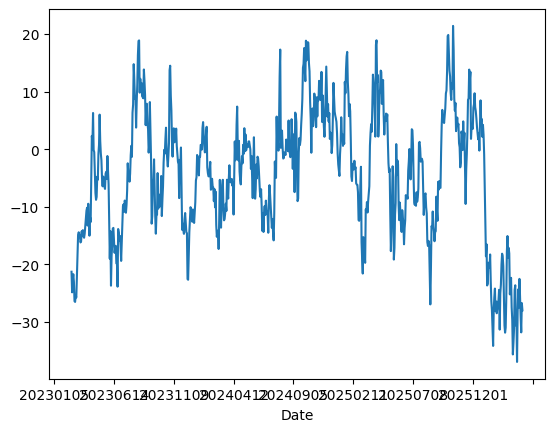

In [6]:
signal_df[:].groupby(['Date','QuoteCode']).TakerSell_CloseBP.mean().reset_index().groupby(['Date']).TakerSell_CloseBP.mean().rolling(30).mean().plot()

In [7]:
signal_df['TakerSell_CloseBP_net'] = signal_df.TakerSell_CloseBP - signal_df.groupby(['Date','QuoteCode']).TakerSell_CloseBP.transform('mean')#.clip(lower=-130, upper=130)
# signal_df['TakerSell_CloseBP_net'] = signal_df.TakerSell_CloseBP - signal_df.groupby(['Date','QuoteCode']).TakerSell_CloseBP.transform('mean')#.clip(lower=-130, upper=130)
# signal_df['TakerSell_CloseBP_net'] = signal_df.TakerSell_CloseBP - signal_df.groupby(['Date']).TakerSell_CloseBP.transform('mean')

In [8]:
signal_df.TakerSell_CloseBP.describe()

count    1.457276e+07
mean     4.424093e+01
std      2.574783e+02
min     -1.060697e+03
25%     -6.973501e+01
50%      4.807692e+01
75%      1.812689e+02
max      1.423877e+03
Name: TakerSell_CloseBP, dtype: float64

In [9]:
import pandas as pd
import json

# 1. 讀取 JSON 檔案還原成 list
with open('abnormal_dates.json', 'r') as f:
    loaded_date_list = json.load(f)

signal_df['isAbnormalDate'] = signal_df['Date'].isin(loaded_date_list) *1

signal_df

,RecvTime,TransTime,QuoteCode,ValueCode,PacketSeq,ChannelSeq,LimitStatus,TrialMatch,InOut,Overshoot,TotalFillLots,BidPrice1,BidPrice2,BidPrice3,BidPrice4,BidPrice5,BidLots1,BidLots2,BidLots3,BidLots4,BidLots5,AskPrice1,AskPrice2,AskPrice3,AskPrice4,AskPrice5,AskLots1,AskLots2,AskLots3,AskLots4,AskLots5,FillPrice,FillLots,BestBidPrice,BestBidLots,BestAskPrice,BestAskLots,OvershootHis,FillLots_origin,RefPrice,OTC,marketOpen,Open,Close,RecordHigh,RecordLow,FutureHigh,FutureLow,ToLow,ToHigh,Low_High,BidPreMove,AskPreMove,TickSize,TickBP,MidPrice,ToRef,ToOpen,FillLots_atLow,FillLots_atHigh,FillLots_Net,B1_A1B1,B1_B1B5,B12_B1B5,A1_A1A5,A12_A1A5,Spread,SpreadPairID,SpreadPairAsk,SpreadPairBid,SpreadPairSeq,SpreadCountAtSameCount,SpreadPairElapsed,SpreadNarrowOrderTime,SpreadNarrowSide,SpreadPairCumLots,PrevSpreadPairLots,SpreadPairTotalCount,RemainSeconds,FutureAsk1_5s,FutureBid1_5s,FutureAsk1_30s,FutureBid1_30s,FutureAsk1_60s,FutureBid1_60s,FutureAsk1_120s,FutureBid1_120s,FutureAsk1_300s,FutureBid1_300s,FutureAsk1_600s,FutureBid1_600s,TakerSell_CloseBP,TakerBuy_CloseBP,midEdge_5sBP,midEdge_30sBP,midEdge_60sBP,midEdge_120sBP,midEdge_300sBP,midEdge_600sBP,allow_day_trade_mark,trading_volume,dealer_hedging_netLots,dealer_netLots,foreign_dealer_netLots,foreign_netLots,investment_netLots,margin_netLots,short_netLots,nextday_allow_day_trade_mark,trading_volume_noOdd,trading_net_volume_noOdd,trading_net_volume_nearClose,avg_bidLots1,avg_askLots1,last_fillLots,last_FillPrice,big_buy_lots,big_buy_ToCloseBP,big_buy_300sBP,big_sell_lots,big_sell_ToCloseBP,big_sell_300sBP,hft_participation,hft_buy_ToCloseBP,hft_buy_300sBP,hft_sell_ToCloseBP,hft_sell_300sBP,hft_strick_participation,hft_strick_buy_ToCloseBP,hft_strick_buy_300sBP,hft_strick_sell_ToCloseBP,hft_strick_sell_300sBP,hft_strick_makerSpreadBP,firstMaker_buy_ToCloseBP,firstMaker_buy_300sBP,firstMaker_sell_ToCloseBP,firstMaker_sell_300sBP,firstMaker_makerSpreadBP,negFill_corr,negFill_sell_ToCloseBP,negFill_sell_300sBP,premium_ref_2330_buy_ToCloseBP,premium_open_2330_buy_ToCloseBP,discount_ref_2330_buy_ToCloseBP,discount_open_2330_buy_ToCloseBP,day_amount_rank,day_lots_rank,TransTime_tb,TimeSlot,AmountRank,netAmountRank,TotalFillLotsRank,netTotalFillLotsRank,ToRefRank,ToOpenRank,ToRefWithOTCRank,ToOpenWithOTCRank,ToOpenNegativeCount,ToOpenPositiveCount,AmountRank_canDayTrade,Date,TakerSell_CloseBP_net,isAbnormalDate
0,2023-01-05 09:00:31.873504,2023-01-05 09:00:31.873504,1101,1101,784333,112210,0,0,-1,1,791,34.25,34.20,34.15,34.10,34.05,143,179,118,51,51,34.35,34.4,34.45,34.5,34.55,52,73,25,248,20,34.25,2,0.0,0,0.0,0,"{""p"":343000,""l"":1}",2,33.5,False,True,34.15,34.45,34.3,34.15,34.7,34.05,0.004478,0.000000,1.000,-0.05,0.0,0.05,14.598540,34.300,0.022388,0.002928,-417,58,-417,0.733333,0.263838,0.594096,0.124402,0.299043,2.0,3,34.35,34.25,1,NaN,0.000000,0.078517,-1.0,2,87,3,15868,34.35,34.30,34.40,34.35,34.40,34.35,34.3,34.25,34.15,34.1,34.25,34.2,-58.394161,29.112082,7.288630,21.865889,21.865889,-7.288630,51.020408,-21.865889,X,10493097.0,182243.0,592000.0,0.0,-3074323.0,27000.0,284.0,-3.0,X,10413.0,3509.0,3046.0,180.302706,242.571005,2254.0,-0.002234,20.0,-30.012817,3.92992,20.0,18.878836,11.791032,0.036689,-44.565533,-9.293680,29.761905,14.869888,0.193744,-29.761905,0.000000,29.761905,29.739777,29.806259,-42.906032,-6.606401,19.135821,-2.127443,-1.653713,-0.998408,17.440131,16.970892,-34.880893,-54.362801,-29.761905,-34.442624,122.0,53.0,NaT,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20230105,0.079017,0
1,2023-01-05 09:00:33.085004,2023-01-05 09:00:33.085004,1101,1101,785653,113530,0,0,0,0,795,34.30,34.25,34.20,34.15,34.10,1,163,185,114,51,34.35,34.4,34.45,34.5,34.55,54,73,25,248,20,0.00,0,0.0,0,0.0,0,NaN,0,33.5,False,True,34.15,34.45,34.3,34.15,34.7,34.05,0.004478,0.000000,1.000,0.05,0.0,0.05,14.577259,34.325,0.023881,0.004392,-413,62,-413,0.018182,0.001946,0.319066,0.128571,0.302381,1.0,3,34.35,34.25,1,1.0,0.081716,0.081716,1.0,6,87,3,15866,34.35,34.30,34.40,34.35,34.40,34.35,34

In [10]:
signal_df['B1_Last'] = signal_df.BidLots1 / signal_df.avg_bidLots1
signal_df['Total_Last'] = signal_df.TotalFillLots / signal_df.last_fillLots


In [11]:
based_columns = ['QuoteCode', 'ChannelSeq', 'InOut', 'Overshoot', 'TotalFillLots', 'BidPrice1','BidLots1', 'BidLots5', 'AskPrice1', 'AskLots1', 'AskLots5', 'FillLots']
feature_columns = ['ToLow', 'ToHigh', 'Low_High', 'TickSize', 'TickBP', 'ToRef', 'ToOpen', 'B1_A1B1', 'B1_B1B5', 'B12_B1B5', 'A1_A1A5', 'A12_A1A5', 'Spread', 'RemainSeconds']#'B1_Last','Total_Last']
cross_columns = ['AmountRank', 'netAmountRank', 'TotalFillLotsRank', 'netTotalFillLotsRank', 'ToRefRank']
day_columns = ['dealer_hedging_netLots', 'dealer_netLots', 'foreign_dealer_netLots', 'foreign_netLots', 'investment_netLots', 'margin_netLots', 'short_netLots', 'nextday_allow_day_trade_mark', 'trading_volume_noOdd', 'big_buy_lots', 'big_buy_ToCloseBP', 'big_buy_300sBP', 'big_sell_lots', 'big_sell_ToCloseBP', 'big_sell_300sBP', 'hft_participation', 'hft_buy_ToCloseBP', 'hft_buy_300sBP', 'hft_sell_ToCloseBP', 'hft_sell_300sBP', 'day_amount_rank', 'day_lots_rank']
# # 
feature = based_columns + feature_columns + cross_columns + day_columns
label = 'TakerSell_CloseBP_net'

feature_columns = ['ToLow', 'ToHigh', 'Low_High', 'ToRef', 'ToOpen', 'B1_A1B1', 'RemainSeconds']

In [12]:
result = train_and_predict_ridge_rolling(signal_df, feature_columns , label, n_training_days=60, feature_screening=True, alpha=0.1 )

🔍 目前預測目標: TakerSell_CloseBP_net | Rolling Training 視窗: 60 天
🔄 為了 O(1) NumPy 加速，強制將資料依照 Date, QuoteCode, TransTime 進行排序...
📊 資料總筆數: 14572759
🔄 填補特徵遺失值 (依據前一交易日之中位數)...
----------------------------------------
🚀 最終使用的 X_list (共 7 個特徵):
['ToLow', 'ToHigh', 'Low_High', 'ToRef', 'ToOpen', 'B1_A1B1', 'RemainSeconds']
----------------------------------------
🔍 檢查是否有「全段期間皆為常數」(Zero Variance) 的特徵...
🔄 計算 Lot Mask (BidPrice1 cumsum) 與準備 NumPy 陣列
🔬 Phase 1: 預先計算 Feature Screening (worker 數: 16, 共 784 天)...
   使用分層取樣 (Stratified Sampling)，每個商品保留 20% 且至少 3 筆


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done   9 tasks      | elapsed:    0.2s
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.3s
[Parallel(n_jobs=16)]: Done  29 tasks      | elapsed:    0.6s
[Parallel(n_jobs=16)]: Done  40 tasks      | elapsed:    0.9s
[Parallel(n_jobs=16)]: Done  53 tasks      | elapsed:    1.3s
[Parallel(n_jobs=16)]: Done  66 tasks      | elapsed:    1.7s
[Parallel(n_jobs=16)]: Done  81 tasks      | elapsed:    2.3s
[Parallel(n_jobs=16)]: Done  96 tasks      | elapsed:    2.8s
[Parallel(n_jobs=16)]: Done 113 tasks      | elapsed:    3.4s
[Parallel(n_jobs=16)]: Done 130 tasks      | elapsed:    4.0s
[Parallel(n_jobs=16)]: Done 149 tasks      | elapsed:    4.9s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    5.6s
[Parallel(n_jobs=16)]: Done 189 tasks      | elapsed:    6.4s
[Parallel(n_jobs=16)]: Done 210 tasks      | elapsed:    7.1s
[Parallel(n_jobs=16)]: Done 233 tasks      | elaps

✅ Phase 1 完成！共 781/784 天有篩選出特徵。
▶️ Phase 2: 開始對 784 個交易日進行 純Numpy極速 平行 Rolling Update (Core 數: -1)...


[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done  49 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done  64 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done  81 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Done  98 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done 117 tasks      | elapsed:    1.5s
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    1.8s
[Parallel(n_jobs=-1)]: Done 157 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Done 178 tasks      | elapsed:    2.6s
[Parallel(n_jobs=-1)]: Done 201 tasks      | elapsed:    3.0s
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    3.3s
[Parallel(n_jobs=-1)]: Done 249 tasks      | elapsed:    3.6s
[Parallel(n_jobs=-1)]: Done 274 tasks      | elapsed:    4.1s
[Parallel(n_jobs=-1)]: Done 301 tasks      | elapsed:    4.5s
[Parallel(n_jobs=-1)]: Done 328 tasks      | elapsed:    4.9s
[Parallel(n_jobs=-1)]: Done 357 tasks      | elapsed:    5.5s
[Paralle

✅ 平行 Rolling 更新預測完成！


In [13]:
screening_log = result['screening_log']   # {日期: [被選中的特徵名]}
coeff_log = result['coeff_log']           # {日期: {normal_coeff, normal_std_coeff, ...}}
signal_df = result['df']           # 原本的 DataFrameㄌ

In [14]:
coeff_log

{'2023-01-06': {'selected_features': ['ToLow',
   'ToHigh',
   'Low_High',
   'ToRef',
   'ToOpen',
   'B1_A1B1',
   'RemainSeconds'],
  'normal_coeff': {'ToLow': -470.0704650878906,
   'ToHigh': -144.5508270263672,
   'Low_High': -2.4011688232421875,
   'ToRef': 1722.206787109375,
   'ToOpen': -354.2607421875,
   'B1_A1B1': -17.66288948059082,
   'RemainSeconds': 0.005171275231987238},
  'normal_std_coeff': {'ToLow': -2.500932455062866,
   'ToHigh': -1.9575716257095337,
   'Low_High': -0.7582514882087708,
   'ToRef': 23.3349552154541,
   'ToOpen': -2.8468081951141357,
   'B1_A1B1': -5.141376495361328,
   'RemainSeconds': 10.18040657043457},
  'normal_intercept': -39.73027420043945},
 '2023-01-09': {'selected_features': ['ToLow',
   'ToHigh',
   'Low_High',
   'ToRef',
   'ToOpen',
   'B1_A1B1',
   'RemainSeconds'],
  'normal_coeff': {'ToLow': -470.0704650878906,
   'ToHigh': -144.5508270263672,
   'Low_High': -2.4011688232421875,
   'ToRef': 1722.206787109375,
   'ToOpen': -354.260742

  Rolling Model Dashboard — NORMAL Model
  交易日數: 783  |  特徵數: 7
  Feature Screening: ON (70/783 天有篩選)

📊 [1/4] Feature Selection Frequency


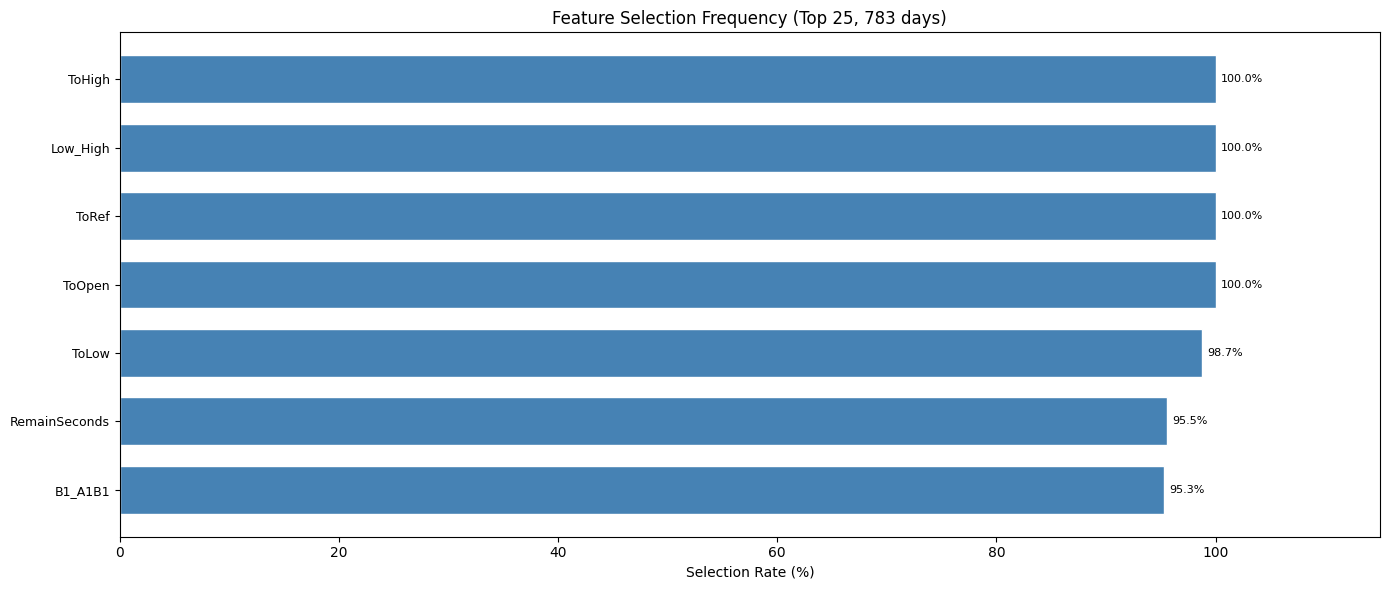


📊 [2/4] Feature Selection Heatmap


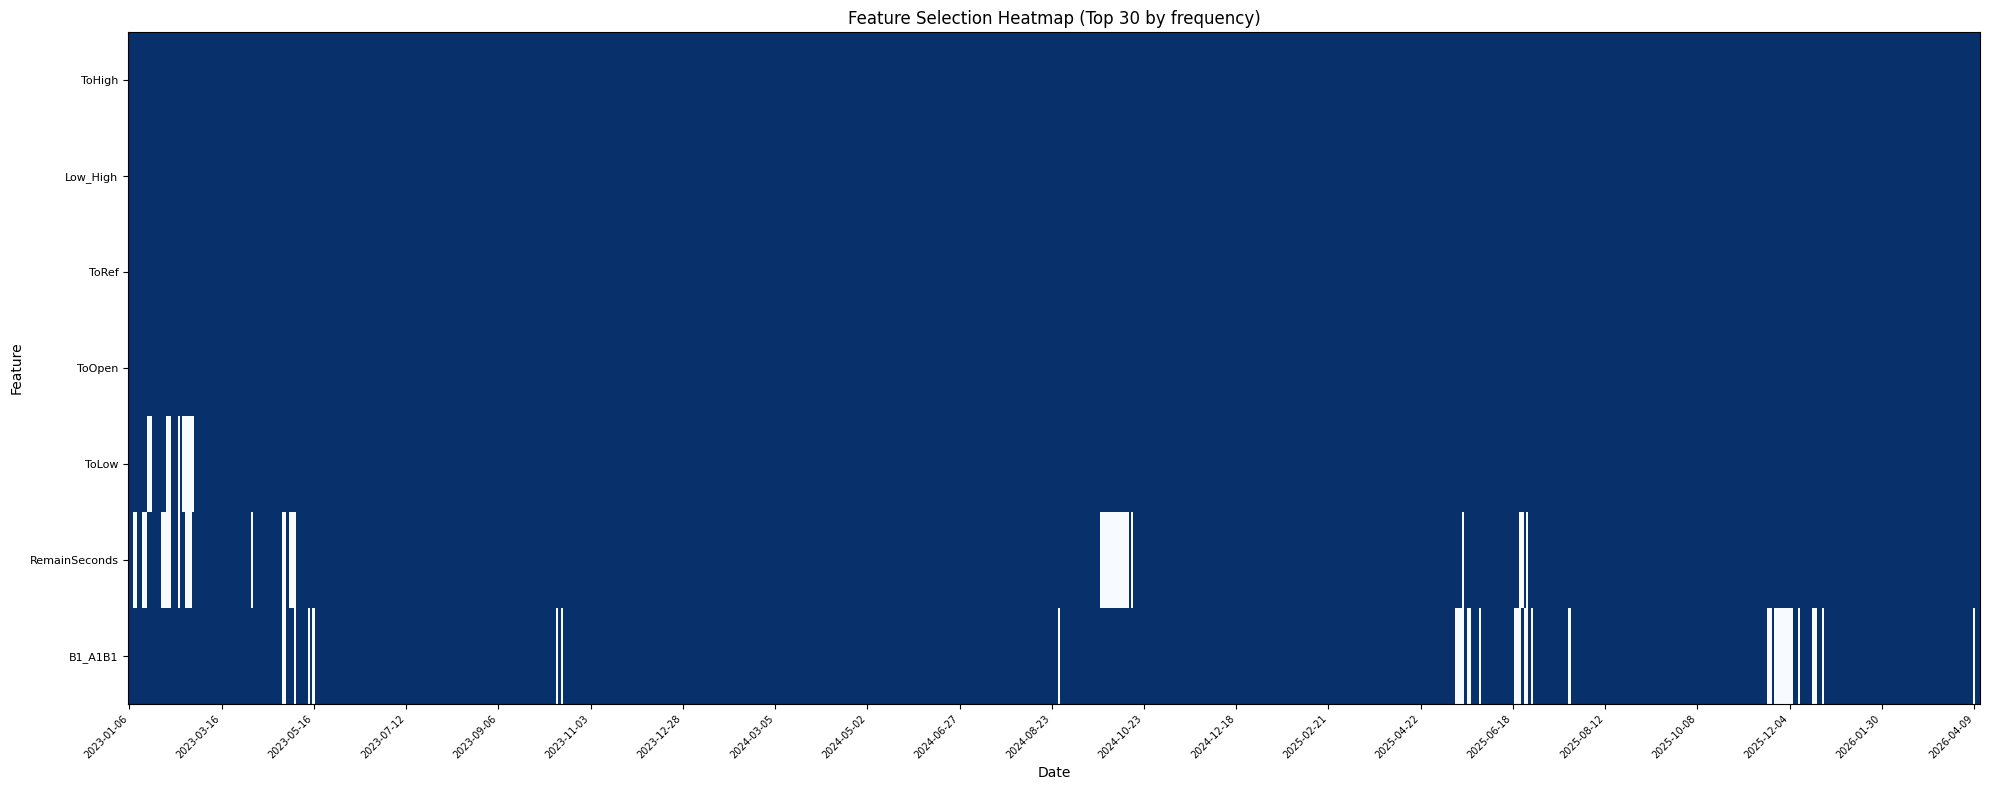


📊 [3/4] Standardized Coefficient Importance


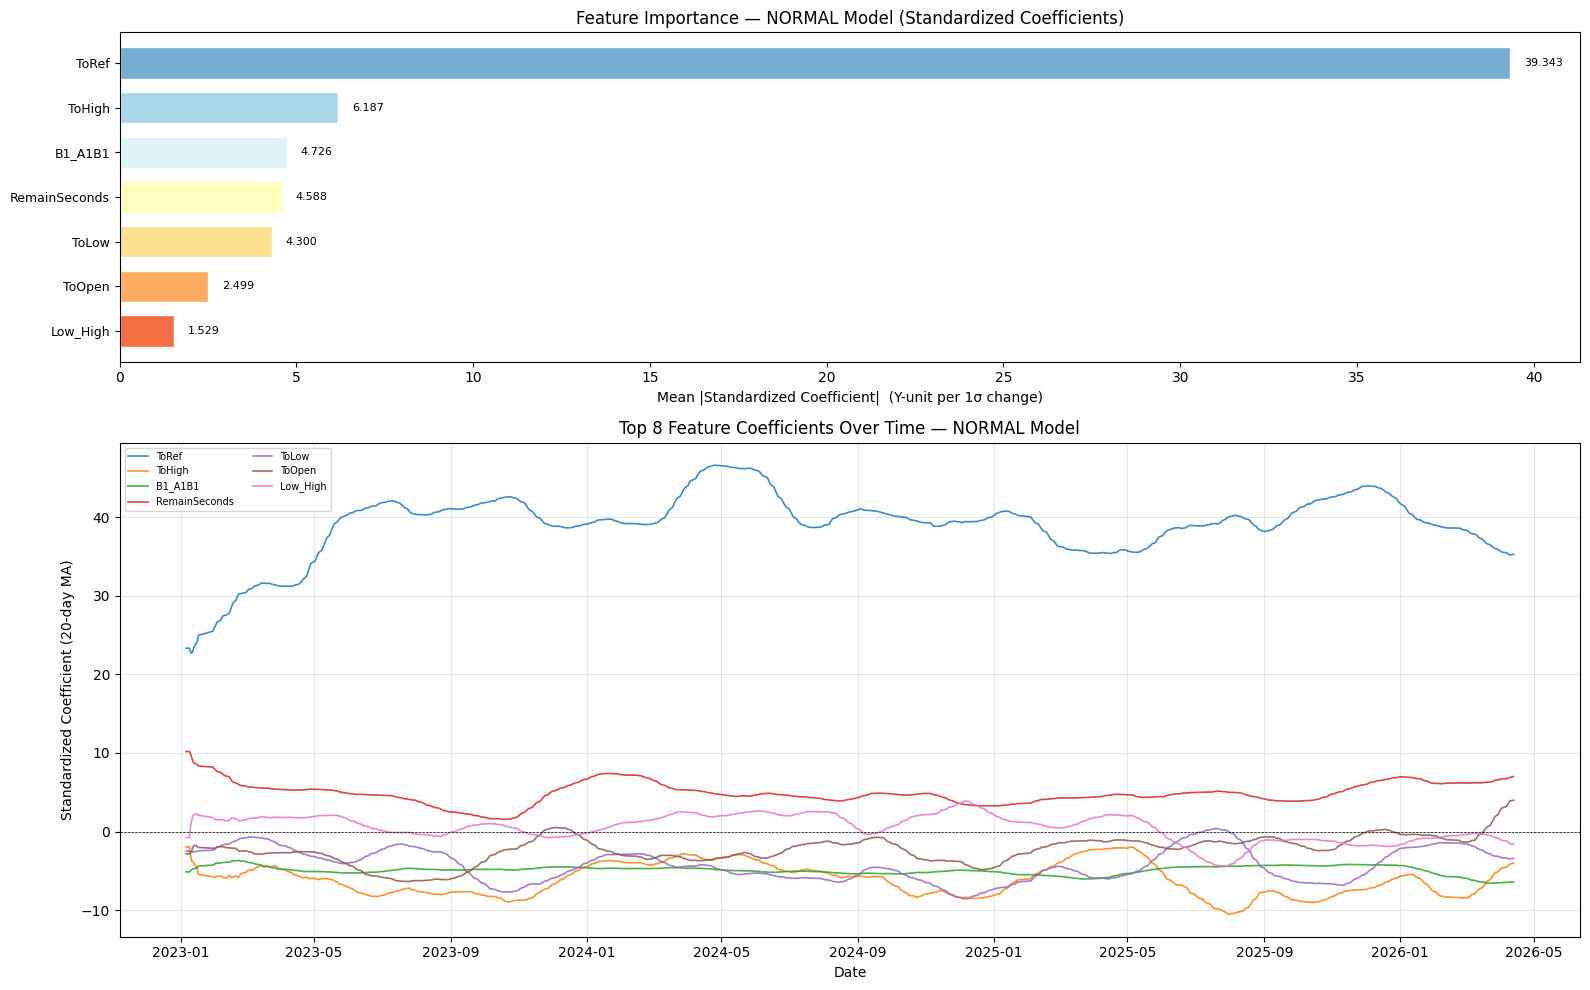


📊 [4/4] Coefficient Stability


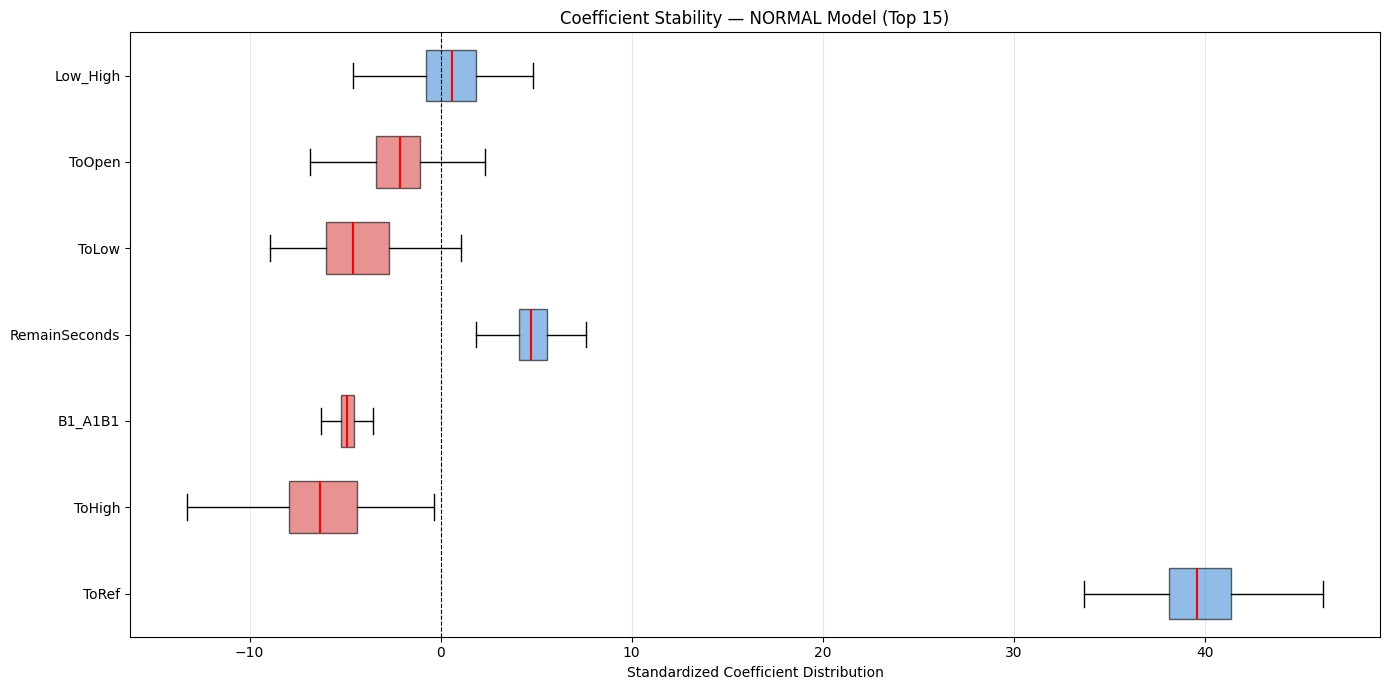

In [15]:
# %load_ext autoreload
# %autoreload 2
from src.research.negFill.model_analysis import plot_model_dashboard
# from model_analysis import plot_model_dashboard

plot_model_dashboard(result, model_type='normal')

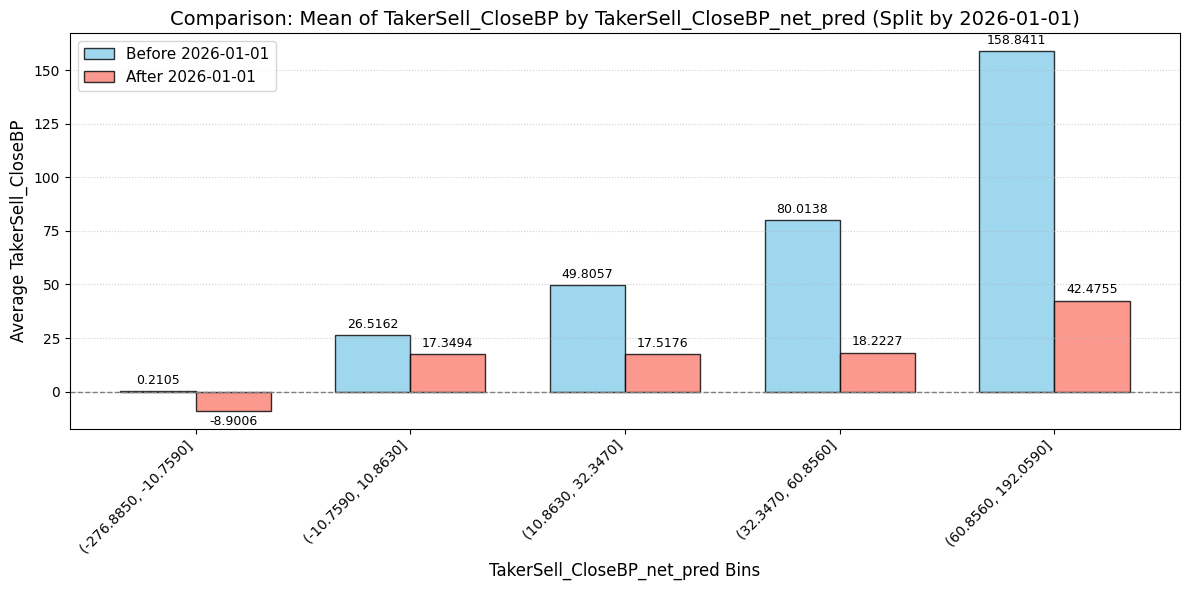

In [16]:
QcutAnalyzer.plot_qcut_analysis(signal_df[signal_df.isAbnormalDate == 0], 'TakerSell_CloseBP_net_pred', 'TakerSell_CloseBP', date_col='Date', split_date='2026-01-01')


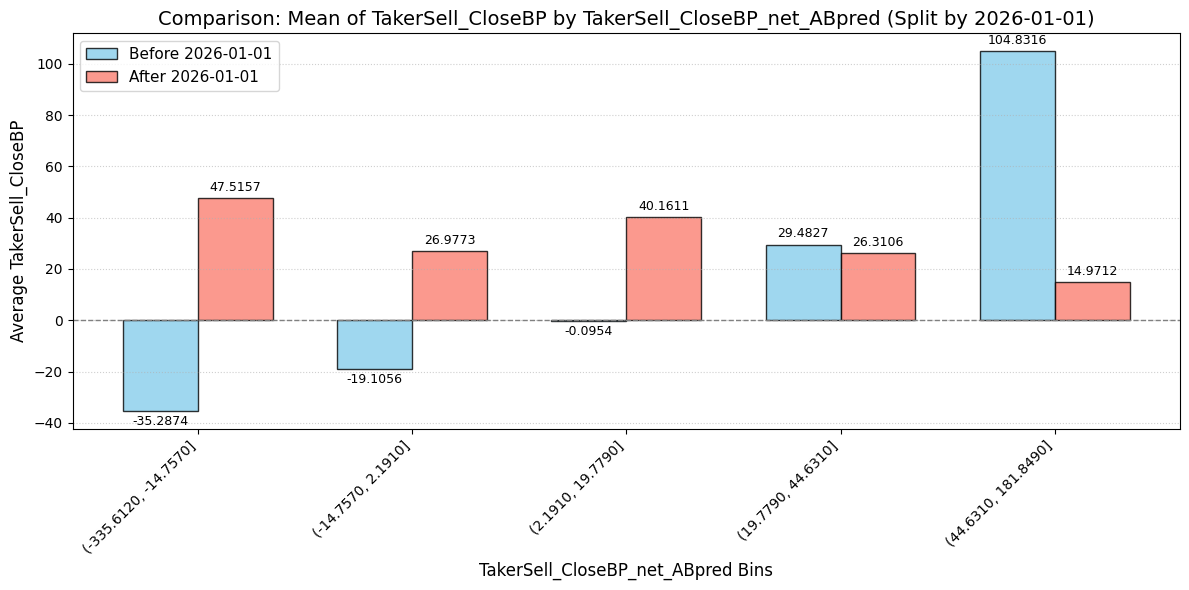

In [17]:
QcutAnalyzer.plot_qcut_analysis(signal_df[signal_df.isAbnormalDate == 1], 'TakerSell_CloseBP_net_ABpred', 'TakerSell_CloseBP', date_col='Date', split_date='2026-01-01')


In [18]:
signal_df.head()

,RecvTime,TransTime,QuoteCode,ValueCode,PacketSeq,ChannelSeq,LimitStatus,TrialMatch,InOut,Overshoot,TotalFillLots,BidPrice1,BidPrice2,BidPrice3,BidPrice4,BidPrice5,BidLots1,BidLots2,BidLots3,BidLots4,BidLots5,AskPrice1,AskPrice2,AskPrice3,AskPrice4,AskPrice5,AskLots1,AskLots2,AskLots3,AskLots4,AskLots5,FillPrice,FillLots,BestBidPrice,BestBidLots,BestAskPrice,BestAskLots,OvershootHis,FillLots_origin,RefPrice,OTC,marketOpen,Open,Close,RecordHigh,RecordLow,FutureHigh,FutureLow,ToLow,ToHigh,Low_High,BidPreMove,AskPreMove,TickSize,TickBP,MidPrice,ToRef,ToOpen,FillLots_atLow,FillLots_atHigh,FillLots_Net,B1_A1B1,B1_B1B5,B12_B1B5,A1_A1A5,A12_A1A5,Spread,SpreadPairID,SpreadPairAsk,SpreadPairBid,SpreadPairSeq,SpreadCountAtSameCount,SpreadPairElapsed,SpreadNarrowOrderTime,SpreadNarrowSide,SpreadPairCumLots,PrevSpreadPairLots,SpreadPairTotalCount,RemainSeconds,FutureAsk1_5s,FutureBid1_5s,FutureAsk1_30s,FutureBid1_30s,FutureAsk1_60s,FutureBid1_60s,FutureAsk1_120s,FutureBid1_120s,FutureAsk1_300s,FutureBid1_300s,FutureAsk1_600s,FutureBid1_600s,TakerSell_CloseBP,TakerBuy_CloseBP,midEdge_5sBP,midEdge_30sBP,midEdge_60sBP,midEdge_120sBP,midEdge_300sBP,midEdge_600sBP,allow_day_trade_mark,trading_volume,dealer_hedging_netLots,dealer_netLots,foreign_dealer_netLots,foreign_netLots,investment_netLots,margin_netLots,short_netLots,nextday_allow_day_trade_mark,trading_volume_noOdd,trading_net_volume_noOdd,trading_net_volume_nearClose,avg_bidLots1,avg_askLots1,last_fillLots,last_FillPrice,big_buy_lots,big_buy_ToCloseBP,big_buy_300sBP,big_sell_lots,big_sell_ToCloseBP,big_sell_300sBP,hft_participation,hft_buy_ToCloseBP,hft_buy_300sBP,hft_sell_ToCloseBP,hft_sell_300sBP,hft_strick_participation,hft_strick_buy_ToCloseBP,hft_strick_buy_300sBP,hft_strick_sell_ToCloseBP,hft_strick_sell_300sBP,hft_strick_makerSpreadBP,firstMaker_buy_ToCloseBP,firstMaker_buy_300sBP,firstMaker_sell_ToCloseBP,firstMaker_sell_300sBP,firstMaker_makerSpreadBP,negFill_corr,negFill_sell_ToCloseBP,negFill_sell_300sBP,premium_ref_2330_buy_ToCloseBP,premium_open_2330_buy_ToCloseBP,discount_ref_2330_buy_ToCloseBP,discount_open_2330_buy_ToCloseBP,day_amount_rank,day_lots_rank,TransTime_tb,TimeSlot,AmountRank,netAmountRank,TotalFillLotsRank,netTotalFillLotsRank,ToRefRank,ToOpenRank,ToRefWithOTCRank,ToOpenWithOTCRank,ToOpenNegativeCount,ToOpenPositiveCount,AmountRank_canDayTrade,Date,TakerSell_CloseBP_net,isAbnormalDate,B1_Last,Total_Last,TakerSell_CloseBP_net_pred,TakerSell_CloseBP_net_ABpred
0,2023-01-05 09:00:31.873504,2023-01-05 09:00:31.873504,1101,1101,784333,112210,0,0,-1,1,791,34.25,34.20,34.15,34.10,34.05,143,179,118,51,51,34.35,34.4,34.45,34.5,34.55,52,73,25,248,20,34.25,2,0.0,0,0.0,0,"{""p"":343000,""l"":1}",2,33.5,False,True,34.15,34.45,34.3,34.15,34.7,34.05,0.004478,0.000000,1.0,-0.05,0.0,0.05,14.598540,34.300,0.022388,0.002928,-417,58,-417,0.733333,0.263838,0.594096,0.124402,0.299043,2.0,3,34.35,34.25,1,NaN,0.000000,0.078517,-1.0,2,87,3,15868,34.35,34.30,34.40,34.35,34.40,34.35,34.3,34.25,34.15,34.1,34.25,34.2,-58.394161,29.112082,7.288630,21.865889,21.865889,-7.288630,51.020408,-21.865889,X,10493097.0,182243.0,592000.0,0.0,-3074323.0,27000.0,284.0,-3.0,X,10413.0,3509.0,3046.0,180.302706,242.571005,2254.0,-0.002234,20.0,-30.012817,3.92992,20.0,18.878836,11.791032,0.036689,-44.565533,-9.29368,29.761905,14.869888,0.193744,-29.761905,0.0,29.761905,29.739777,29.806259,-42.906032,-6.606401,19.135821,-2.127443,-1.653713,-0.998408,17.440131,16.970892,-34.880893,-54.362801,-29.761905,-34.442624,122.0,53.0,NaT,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-01-05,0.079017,0,0.793111,0.350932,NaN,NaN
1,2023-01-05 09:00:33.085004,2023-01-05 09:00:33.085004,1101,1101,785653,113530,0,0,0,0,795,34.30,34.25,34.20,34.15,34.10,1,163,185,114,51,34.35,34.4,34.45,34.5,34.55,54,73,25,248,20,0.00,0,0.0,0,0.0,0,NaN,0,33.5,False,True,34.15,34.45,34.3,34.15,34.7,34.05,0.004478,0.000000,1.0,0.05,0.0,0.05,14.577259,34.325,0.023881,0.004392,-413,62,-413,0.018182,0.001946,0.319066,0.128571,0.302381,1.0,

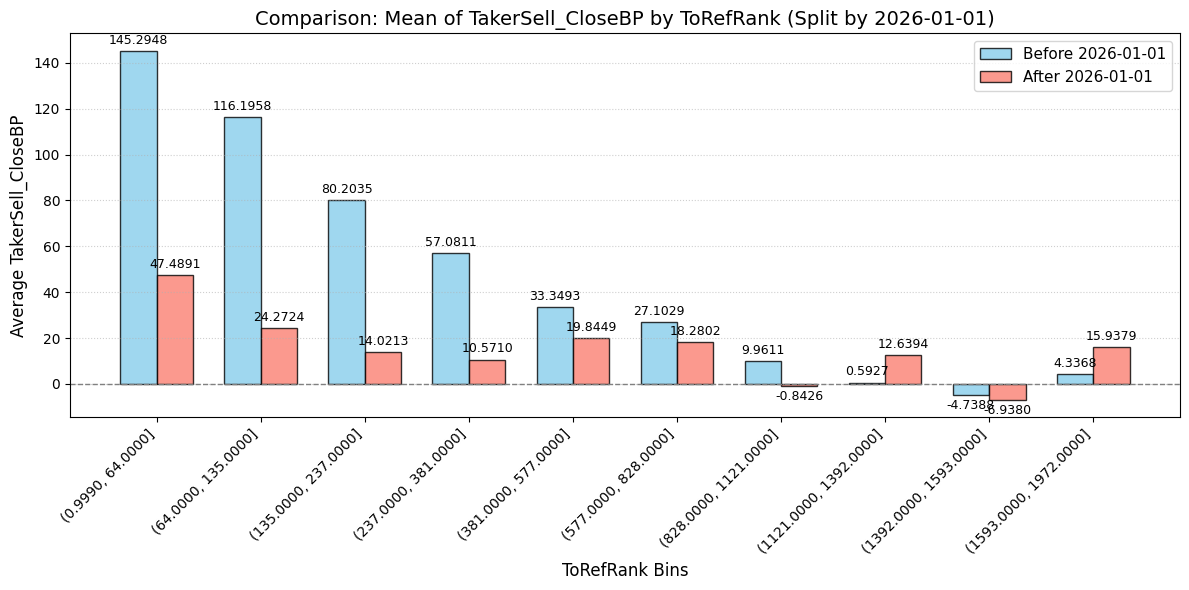

In [19]:
QcutAnalyzer.plot_qcut_analysis(signal_df[:], 'ToRefRank', 'TakerSell_CloseBP', date_col='Date', split_date='2026-01-01',q=10)


In [20]:
condition = pd.Series( [True for i in range(len(signal_df))] )
# condition =   (signal_df.ToOpen <0)# (signal_df.Position<200) #(signal_df.big_sell_ToCloseBP > 20 ) & (signal_df.InOut < 0 ) & (signal_df.FillLots > signal_df.big_sell_lots)
# condition = condition | ((signal_df.Spread <= 1 ) & ((signal_df.SpreadPairSeq>5) & (signal_df.SpreadPairID > 5)))
condition = condition & (( signal_df.TakerSell_CloseBP_net_pred * (signal_df.isAbnormalDate == 0 ) > 40) | ( signal_df.TakerSell_CloseBP_net_ABpred * (signal_df.isAbnormalDate == 1 ) > 60)) #&(signal_df.SpreadCountAtSameCount <= 1)#& (signal_df.TakerSell_CloseBP_net_pred > 0) #& ((signal_df.netTotalFillLotsRank>1800)|(signal_df.netAmountRank>1800))
print( signal_df[condition].TakerSell_CloseBP.describe() )
print('')
print( 'cap BP : '+str( round((signal_df[condition].TakerSell_CloseBP * signal_df[condition].BidPrice1).sum() / signal_df[condition].BidPrice1.sum() ,2 ))  )
print( 'averge prod num : '+str( round(signal_df[condition].groupby('Date').QuoteCode.nunique().mean(), 2)  ))

condition_recent = condition & (signal_df.Date.astype(int) > 20260101) # & (signal_df.Date.dt.strftime('%Y%m%d').astype(int) > 20260101) #& (signal_df.hft_participation > 0.3) & (signal_df.hft_sell_ToCloseBP > 0 )
print( signal_df[condition_recent].TakerSell_CloseBP.describe() ) 
print('')
print( 'cap BP : '+str( round((signal_df[condition_recent].TakerSell_CloseBP * signal_df[condition_recent].BidPrice1).sum() / signal_df[condition_recent].BidPrice1.sum() ,2 ))  )
print( 'averge prod num : '+str( round(signal_df[condition_recent].groupby('Date').QuoteCode.nunique().mean(), 2)  ))

count    3.900893e+06
mean     1.162782e+02
std      3.081852e+02
min     -8.457711e+02
25%     -2.257336e+01
50%      1.742160e+02
75%      3.040541e+02
max      1.423877e+03
Name: TakerSell_CloseBP, dtype: float64

cap BP : 92.32
averge prod num : 69.6
count    3.900893e+06
mean     1.162782e+02
std      3.081852e+02
min     -8.457711e+02
25%     -2.257336e+01
50%      1.742160e+02
75%      3.040541e+02
max      1.423877e+03
Name: TakerSell_CloseBP, dtype: float64

cap BP : 92.32
averge prod num : 69.6


In [21]:
signal_df = signal_df[condition].sort_values(['Date','QuoteCode', 'TransTime']).reset_index(drop=True)

In [22]:
signal_df.head()

,RecvTime,TransTime,QuoteCode,ValueCode,PacketSeq,ChannelSeq,LimitStatus,TrialMatch,InOut,Overshoot,TotalFillLots,BidPrice1,BidPrice2,BidPrice3,BidPrice4,BidPrice5,BidLots1,BidLots2,BidLots3,BidLots4,BidLots5,AskPrice1,AskPrice2,AskPrice3,AskPrice4,AskPrice5,AskLots1,AskLots2,AskLots3,AskLots4,AskLots5,FillPrice,FillLots,BestBidPrice,BestBidLots,BestAskPrice,BestAskLots,OvershootHis,FillLots_origin,RefPrice,OTC,marketOpen,Open,Close,RecordHigh,RecordLow,FutureHigh,FutureLow,ToLow,ToHigh,Low_High,BidPreMove,AskPreMove,TickSize,TickBP,MidPrice,ToRef,ToOpen,FillLots_atLow,FillLots_atHigh,FillLots_Net,B1_A1B1,B1_B1B5,B12_B1B5,A1_A1A5,A12_A1A5,Spread,SpreadPairID,SpreadPairAsk,SpreadPairBid,SpreadPairSeq,SpreadCountAtSameCount,SpreadPairElapsed,SpreadNarrowOrderTime,SpreadNarrowSide,SpreadPairCumLots,PrevSpreadPairLots,SpreadPairTotalCount,RemainSeconds,FutureAsk1_5s,FutureBid1_5s,FutureAsk1_30s,FutureBid1_30s,FutureAsk1_60s,FutureBid1_60s,FutureAsk1_120s,FutureBid1_120s,FutureAsk1_300s,FutureBid1_300s,FutureAsk1_600s,FutureBid1_600s,TakerSell_CloseBP,TakerBuy_CloseBP,midEdge_5sBP,midEdge_30sBP,midEdge_60sBP,midEdge_120sBP,midEdge_300sBP,midEdge_600sBP,allow_day_trade_mark,trading_volume,dealer_hedging_netLots,dealer_netLots,foreign_dealer_netLots,foreign_netLots,investment_netLots,margin_netLots,short_netLots,nextday_allow_day_trade_mark,trading_volume_noOdd,trading_net_volume_noOdd,trading_net_volume_nearClose,avg_bidLots1,avg_askLots1,last_fillLots,last_FillPrice,big_buy_lots,big_buy_ToCloseBP,big_buy_300sBP,big_sell_lots,big_sell_ToCloseBP,big_sell_300sBP,hft_participation,hft_buy_ToCloseBP,hft_buy_300sBP,hft_sell_ToCloseBP,hft_sell_300sBP,hft_strick_participation,hft_strick_buy_ToCloseBP,hft_strick_buy_300sBP,hft_strick_sell_ToCloseBP,hft_strick_sell_300sBP,hft_strick_makerSpreadBP,firstMaker_buy_ToCloseBP,firstMaker_buy_300sBP,firstMaker_sell_ToCloseBP,firstMaker_sell_300sBP,firstMaker_makerSpreadBP,negFill_corr,negFill_sell_ToCloseBP,negFill_sell_300sBP,premium_ref_2330_buy_ToCloseBP,premium_open_2330_buy_ToCloseBP,discount_ref_2330_buy_ToCloseBP,discount_open_2330_buy_ToCloseBP,day_amount_rank,day_lots_rank,TransTime_tb,TimeSlot,AmountRank,netAmountRank,TotalFillLotsRank,netTotalFillLotsRank,ToRefRank,ToOpenRank,ToRefWithOTCRank,ToOpenWithOTCRank,ToOpenNegativeCount,ToOpenPositiveCount,AmountRank_canDayTrade,Date,TakerSell_CloseBP_net,isAbnormalDate,B1_Last,Total_Last,TakerSell_CloseBP_net_pred,TakerSell_CloseBP_net_ABpred
0,2023-01-09 09:01:06.653871,2023-01-09 09:01:06.653871,1101,1101,824983,166088,0,0,-1,0,655,34.50,34.45,34.40,34.35,34.30,13,21,20,37,46,34.60,34.65,34.70,34.75,34.80,31,60,259,131,212,34.55,61,0.0,0,0.0,0,NaN,61,34.25,False,True,34.6,34.6,34.65,34.55,34.6,34.35,0.0,0.00292,0.0,-0.05,0.0,0.05,14.492754,34.550,0.007299,-0.002890,-74,-71,321,0.295455,0.094891,0.248175,0.044733,0.131313,2.0,2,34.60,34.50,1,NaN,0.000000,0.031769,-1.0,61,150,2,15833,34.55,34.50,34.55,34.45,34.5,34.45,34.50,34.45,34.55,34.50,34.50,34.45,-28.985507,0.00000,-7.235890,-14.471780,-21.707670,-21.707670,7.235890,-21.707670,X,13688284.0,-29518.0,237000.0,0.0,-3396381.0,74000.0,20.0,12.0,X,13535.0,-2985.0,-2266.0,203.182755,119.484816,2020.0,0.00073,10.0,-22.658432,3.327094,20.0,6.296735,9.06161,0.024258,-29.112082,0.0,-3.729424,1.807588,0.11834,NaN,NaN,-14.654132,2.913328,-58.055152,-42.270775,-9.684815,-3.003369,4.344928,-21.338506,-0.758115,-12.57147,-0.081443,-66.158934,-72.463768,-6.582602,-21.476834,97.0,31.0,NaT,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-01-09,11.999632,0,0.063982,0.324257,50.100101,23.637722
1,2023-01-09 09:01:30.634383,2023-01-09 09:01:30.634383,1101,1101,855455,196560,0,0,-1,0,699,34.45,34.40,34.35,34.30,34.25,23,22,35,35,221,34.55,34.60,34.65,34.70,34.75,80,99,82,187,147,34.50,19,0.0,0,0.0,0,NaN,19,34.25,False,True,34.6,34.6,34.65,34.50,34.6,34.35,0.0,0.00438,0.0,-0.05,0.0,0.05,14.513788,34.500,0.005839,-0.004335,-42,-113,279,0.223301,0.068452,0.133929,0.134454,0.300840,2.0,3,34.55,34.45,1,NaN,0.

In [96]:
signal_df['PosLots'] = signal_df.groupby(['Date', 'QuoteCode']).BidPrice1.transform('cumcount') + 1
signal_df['Position'] = signal_df.groupby(['Date', 'QuoteCode']).BidPrice1.transform('cumsum') / 10
signalwithRisk_df = signal_df[  
(signal_df.Position < 200)
#  (~((signal_df.PosLots >1) & (signal_df.Position > 15))) & (signal_df.BidPrice1<150)
# ( ((signal_df.Position < 500)&((signal_df.AmountRank < 50) | (signal_df.day_amount_rank<50))) |((signal_df.Position < 200)&((signal_df.AmountRank < 100) | (signal_df.day_amount_rank<100))) | ((signal_df.Position < 100)))
& (signal_df.BidPrice1<1000) 
& ( (signal_df.hft_strick_makerSpreadBP > -70) | (signal_df.hft_strick_makerSpreadBP.isna()))
#  & ((signal_df.AmountRank<100) |(signal_df.day_amount_rank < 100))
#  & ((signal_df.ToRef>0))
      ].reset_index(drop=True)
# signalwithRisk_df = signal_df[ (signal_df.PosLots ==1) & (signal_df.BidPrice1 <= 100)].reset_index(drop=True)


In [97]:
# signalwithRisk_df['totalPosition'] = signalwithRisk_df.groupby(['Date']).BidPrice1.transform('cumsum') / 10

# signalwithRisk_df = signalwithRisk_df[ (signalwithRisk_df.totalPosition <= 15000 )].reset_index(drop=True)

for d in signalwithRisk_df[lambda x : x.Date.astype(int) > 20260404].Date.unique() :
    signalwithRisk_df[lambda x : x.Date == d].reset_index(drop=True).to_csv(f'{d}_10w.csv')

In [98]:
signalwithRisk_df['Date'] = signalwithRisk_df.Date.dt.strftime('%Y%m%d')

signalwithRisk_df[ signalwithRisk_df.Date.astype(int) == signalwithRisk_df.Date.astype(int).max() ].QuoteCode.unique()

<ArrowStringArray>
['1303', '1711', '1717', '1727', '1802', '1815', '2313', '2316', '2327',
 '2351', '2367', '2404', '2408', '2449', '2467', '2486', '2731', '3006',
 '3026', '3030', '3042', '3062', '3105', '3260', '3583', '3689', '3693',
 '3702', '3711', '4566', '4576', '4749', '4764', '4908', '4949', '5439',
 '5443', '5483', '5498', '5536', '6127', '6190', '6196', '6217', '6265',
 '6271', '6274', '6285', '6443', '6451', '6488', '6588', '6725', '6761',
 '6789', '6903', '7717', '8021', '8039', '8064', '8074', '8096', '8358']
Length: 63, dtype: str

In [99]:
signalwithRisk_df[ (signalwithRisk_df.Date.astype(int) == signalwithRisk_df.Date.astype(int).max()) & (signalwithRisk_df.FutureHigh > signalwithRisk_df.RefPrice *1.08) ].QuoteCode.unique()

<ArrowStringArray>
['1711', '1802', '2327', '2449', '3026', '3042', '3062', '3689', '3693',
 '3711', '4566', '4576', '4764', '4908', '4949', '5439', '6217', '6285',
 '6451', '6761', '6789', '8021', '8064', '8358']
Length: 24, dtype: str

In [100]:
# 計算所有天數的排名比例
series1 = ( signalwithRisk_df.BidPrice1 * (signalwithRisk_df.TakerSell_CloseBP - 19.3) / 10000 / 10).groupby(signalwithRisk_df.Date).sum()
position = (signalwithRisk_df.BidPrice1 / 10).groupby(signalwithRisk_df.Date).sum()

rank_series = series1.rank(pct=True)

dateSeq = -1

# 取得最後一天的排名
latest_date = series1.index[dateSeq]
latest_rank = rank_series.iloc[dateSeq]

print(f"日期: {latest_date}")
print(f"單邊部位: {position.iloc[dateSeq]:.2f} 萬")
print(f"損益: {series1.iloc[dateSeq]:.2f} 萬")

rank_series = series1.rank()
latest_rank2 = rank_series.iloc[dateSeq]
print(f"排名: {latest_rank2},  {latest_rank :.2%}") # 例如 85.00%，代表贏過歷史 85% 的天數




日期: 20260413
單邊部位: 9917.89 萬
損益: -233.25 萬
排名: 2.0,  0.26%


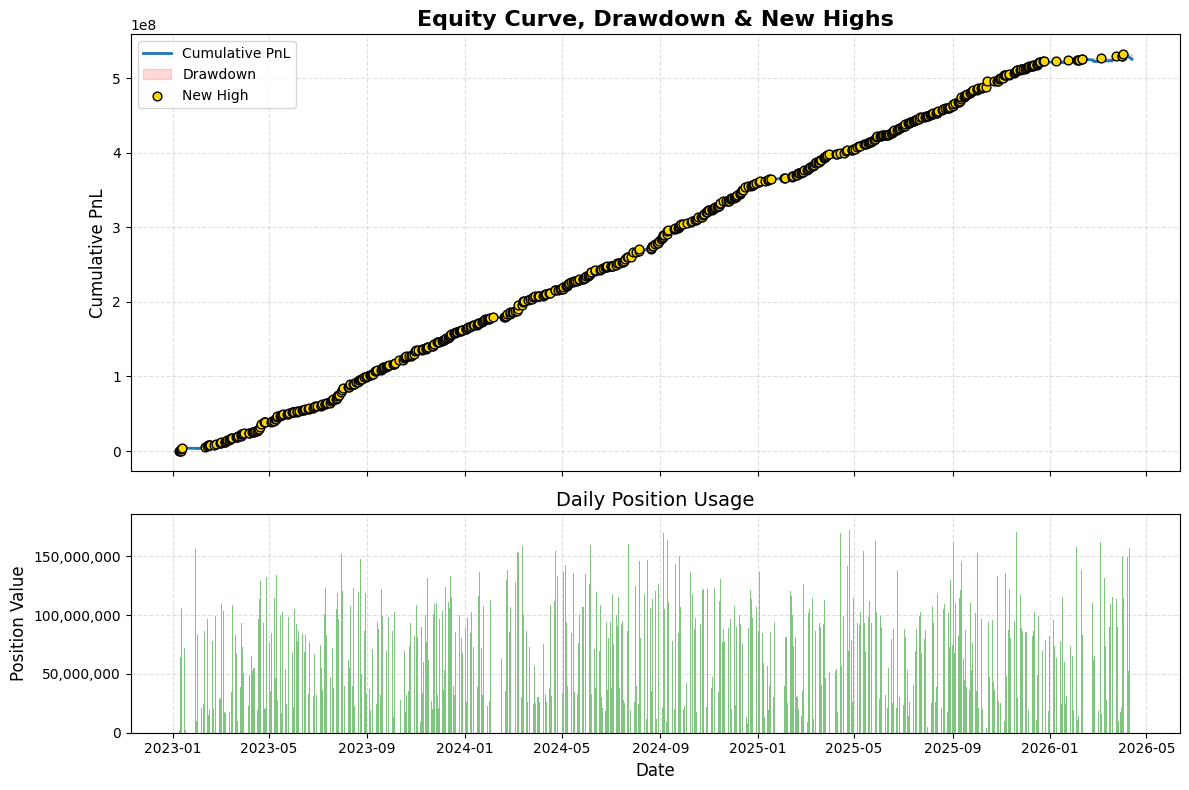


指標                 | 數值           

------------------ 基礎回報 ------------------
總報酬 (萬)           : 52,512.53
近一年報酬（萬）      : 12,622.92
風報比                  : 76.78
年化 Sharpe          : 10.64
創高最長費時 (天)     : 12
平均每日交易商品數   : 52.00

------------------ 勝率與效率 ------------------
年報酬率（基於平均部位）: 216.92%
近一年報酬率（近一年平均部位）: 171.79%
勝率 (日/單筆)      : 79.90% / 71.41%
平均BP (單/單位)   : 92.93 / 90.3854

------------------ 風控與部位 ------------------
單日最大虧損（萬） : -336.93 萬
MDD金額/佔平均比   : -683.95 萬 / 9.19%
平均/最大部位(萬)  : 7,438.99 / 17,669.07
平均最大單一商品比  : 4.62%



In [101]:
bt = BackTest(signalwithRisk_df)
results = bt.run_analysis()

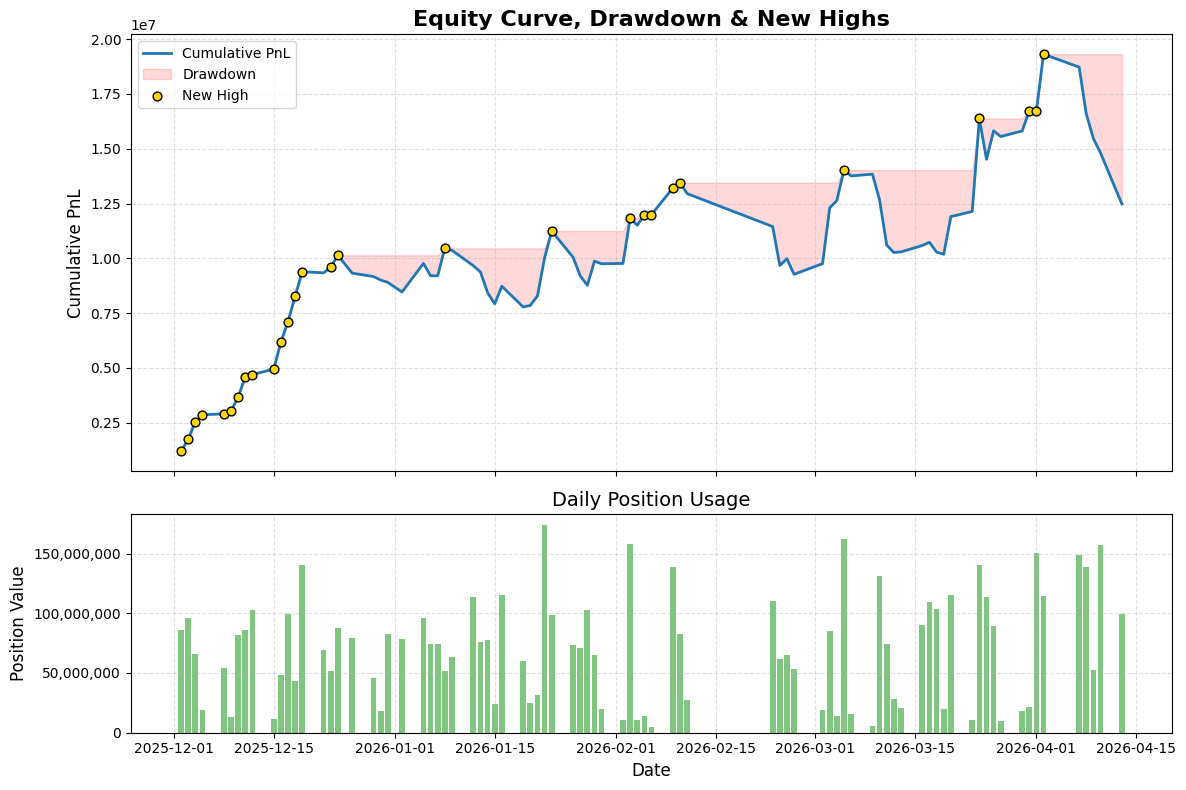


指標                 | 數值           

------------------ 基礎回報 ------------------
總報酬 (萬)           : 1,247.64
近一年報酬（萬）      : 1,247.64
風報比                  : 1.82
年化 Sharpe          : 2.20
創高最長費時 (天)     : 12
平均每日交易商品數   : 48.14

------------------ 勝率與效率 ------------------
年報酬率（基於平均部位）: 50.37%
近一年報酬率（近一年平均部位）: 17.42%
勝率 (日/單筆)      : 56.63% / 58.38%
平均BP (單/單位)   : 41.49 / 20.9865

------------------ 風控與部位 ------------------
單日最大虧損（萬） : -233.25 萬
MDD金額/佔平均比   : -683.95 萬 / 9.55%
平均/最大部位(萬)  : 7,162.59 / 17,413.15
平均最大單一商品比  : 5.84%



In [102]:
bt = BackTest(signalwithRisk_df[signalwithRisk_df.Date.astype(int) > 20251201])
results = bt.run_analysis()


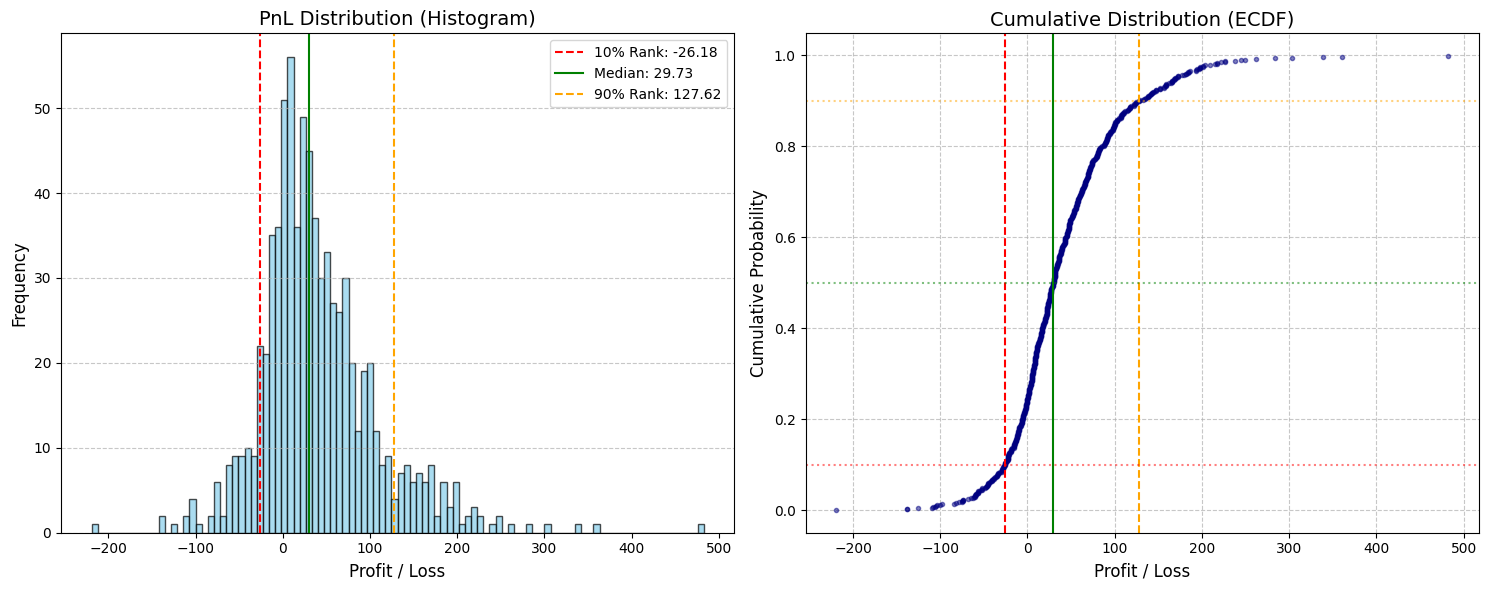

In [94]:

# 1. 計算分位數數值
q10 = series1.quantile(0.1)
q50 = series1.quantile(0.5)
q90 = series1.quantile(0.9)

# 2. 排序數據以計算累積機率 (ECDF)
sorted_data = np.sort(series1)
y_values = np.arange(len(sorted_data)) / float(len(sorted_data))

# 建立畫布
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- 圖左：直方圖 (棒狀圖) ---
axes[0].hist(series1, bins=100, color='skyblue', edgecolor='black', alpha=0.7)
# 加入垂直分界線
axes[0].axvline(q10, color='red', linestyle='--', linewidth=1.5, label=f'10% Rank: {q10:.2f}')
axes[0].axvline(q50, color='green', linestyle='-', linewidth=1.5, label=f'Median: {q50:.2f}')
axes[0].axvline(q90, color='orange', linestyle='--', linewidth=1.5, label=f'90% Rank: {q90:.2f}')

axes[0].set_title('PnL Distribution (Histogram)', fontsize=14)
axes[0].set_xlabel('Profit / Loss', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].legend() # 顯示圖例
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# --- 圖右：累積圖 (ECDF) ---
axes[1].plot(sorted_data, y_values, marker='.', linestyle='none', color='navy', alpha=0.5)
# 加入垂直分界線 (X軸：損益數值)
axes[1].axvline(q10, color='red', linestyle='--', linewidth=1.5)
axes[1].axvline(q50, color='green', linestyle='-', linewidth=1.5)
axes[1].axvline(q90, color='orange', linestyle='--', linewidth=1.5)
# 加入水平參考線 (Y軸：排名百分比)
axes[1].axhline(0.1, color='red', linestyle=':', alpha=0.5)
axes[1].axhline(0.5, color='green', linestyle=':', alpha=0.5)
axes[1].axhline(0.9, color='orange', linestyle=':', alpha=0.5)

axes[1].set_title('Cumulative Distribution (ECDF)', fontsize=14)
axes[1].set_xlabel('Profit / Loss', fontsize=12)
axes[1].set_ylabel('Cumulative Probability', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [95]:
# 計算所有天數的排名比例
series1 = ( signalwithRisk_df.BidPrice1 * (signalwithRisk_df.TakerSell_CloseBP - 19.3) / 10000 / 10).groupby(signalwithRisk_df.Date).sum()


In [32]:
date_portfolio = series1.reset_index().rename(columns={0: 'PL'})
date_portfolio['Position'] = ( signalwithRisk_df.BidPrice1 / 10).groupby(signalwithRisk_df.Date).sum().reset_index(drop=True)
date_portfolio['Return'] = date_portfolio['PL'] / date_portfolio['Position'] * 100

In [33]:
date_portfolio.describe()

,PL,Position,Return
count,781.000000,781.000000,781.000000
mean,67.237558,7438.987697,0.926138
std,100.290356,4139.915759,1.147131
min,-336.934754,257.270000,-4.200163
25%,7.880541,3386.520000,0.161091
50%,47.785729,8021.945000,1.026979
75%,115.386750,10573.194000,1.667172
max,711.782837,17669.070000,4.318560


【分析 A】2025 以後 兩者報酬與風險特性：
- 獲利率 Pearson 相關性: -0.5264
- 0030_portfolio  : 日波動 1.9419 | 年化波動度 30.8261
- date_portfolio  : 日波動 1.2710 | 年化波動度 20.1761

【分析 B】2025 以後 各自賠最多的 20% 交易日重疊狀況：
- 在 0030_portfolio 最差的 61 天中，有 3.28% 的機率 date_portfolio 也處於極端虧損
- 在 date_portfolio 最差的 61 天中，有 3.28% 的機率 0030 也處於極端虧損



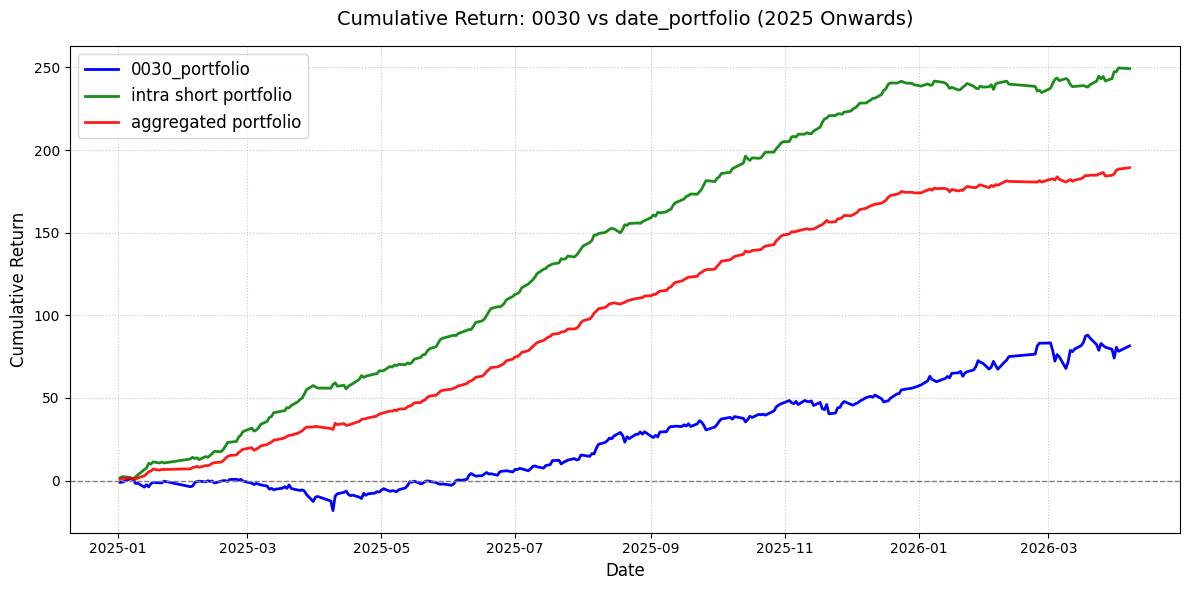

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------------------------
# 1. 讀取並處理 0030_portfolio.csv
# -------------------------------------------------------------------------
df_0030 = pd.read_csv('/home/kevin/Project/HFT/src/research/negFill/0030_portfolio.csv', encoding='utf-8-sig')

# 將 0030 的日期轉為 datetime 格式，方便後續篩選
df_0030['日期'] = pd.to_datetime(df_0030['日期'].astype(str), format='%Y%m%d')

# 👉 更正 1：篩選 2025 以後（包含 2025-01-01）
df_0030_filtered = df_0030[df_0030['日期'] >= '2025-01-01'].copy()
df_0030_filtered['獲利率'] = df_0030_filtered['獲利率'] * 100


# -------------------------------------------------------------------------
# 2. 處理 date_portfolio，對齊年份與格式
# -------------------------------------------------------------------------
# 👉 請確認這兩個變數對應您 date_portfolio 的實際欄位名稱：
date_col = 'Date'        # 日期欄位名稱
return_col = 'Return'    # 獲利率欄位名稱

dp_filtered = date_portfolio.copy()

# 若 date_portfolio 的日期在 index 上，請解除下面這行註解：
# dp_filtered = dp_filtered.reset_index() 

# 將該欄位轉為 datetime 格式，並篩選 2025 以後的資料
dp_filtered[date_col] = pd.to_datetime(dp_filtered[date_col].astype(str)) 
dp_filtered = dp_filtered[dp_filtered[date_col] >= '2025-01-01'].copy()


# -------------------------------------------------------------------------
# 合併兩者（取每日均有交易的交集日），並確保日期順序
# -------------------------------------------------------------------------
merged_df = pd.merge(
    df_0030_filtered[['日期', '獲利率']], 
    dp_filtered[[date_col, return_col]], 
    left_on='日期', 
    right_on=date_col, 
    how='inner'
)
merged_df = merged_df.sort_values('日期').reset_index(drop=True)


# =========================================================
# 分析 A：獲利率相關性與波動度
# =========================================================
correlation = merged_df['獲利率'].corr(merged_df[return_col])

# 👉 新增 2：計算波動度 (日標準差及乘上根號 252 的年化標準差)
vol_0030_daily = merged_df['獲利率'].std()
vol_0030_annual = vol_0030_daily * np.sqrt(252)

vol_dp_daily = merged_df[return_col].std()
vol_dp_annual = vol_dp_daily * np.sqrt(252)

print("【分析 A】2025 以後 兩者報酬與風險特性：")
print(f"- 獲利率 Pearson 相關性: {correlation:.4f}")
print(f"- 0030_portfolio  : 日波動 {vol_0030_daily:.4f} | 年化波動度 {vol_0030_annual:.4f}")
print(f"- date_portfolio  : 日波動 {vol_dp_daily:.4f} | 年化波動度 {vol_dp_annual:.4f}\n")


# =========================================================
# 分析 B：各自賠最多的 20% 交易日的重疊率 (基於原始 2025 以後的區間)
# =========================================================
thresh_0030 = df_0030_filtered['獲利率'].quantile(0.2)
thresh_dp = dp_filtered[return_col].quantile(0.2)

worst_days_0030 = set(df_0030_filtered[df_0030_filtered['獲利率'] <= thresh_0030]['日期'])
worst_days_dp = set(dp_filtered[dp_filtered[return_col] <= thresh_dp][date_col])

overlap_days = worst_days_0030.intersection(worst_days_dp)
union_days = worst_days_0030.union(worst_days_dp)

rate_0030 = len(overlap_days) / len(worst_days_0030) if len(worst_days_0030) > 0 else 0
rate_dp = len(overlap_days) / len(worst_days_dp) if len(worst_days_dp) > 0 else 0

print("【分析 B】2025 以後 各自賠最多的 20% 交易日重疊狀況：")
print(f"- 在 0030_portfolio 最差的 {len(worst_days_0030)} 天中，有 {rate_0030:.2%} 的機率 date_portfolio 也處於極端虧損")
print(f"- 在 date_portfolio 最差的 {len(worst_days_dp)} 天中，有 {rate_dp:.2%} 的機率 0030 也處於極端虧損\n")


# =========================================================
# 分析 C：繪製 2025 以後累計獲利率 (CumSum) 比較圖
# =========================================================
# 👉 新增 3：計算 CumSum 並畫在同一張圖
merged_df['0030_cumsum'] = merged_df['獲利率'].cumsum()
merged_df['dp_cumsum'] = merged_df[return_col].cumsum()

plt.figure(figsize=(12, 6))

# 把累進獲利畫出來
plt.plot(merged_df['日期'], merged_df['0030_cumsum'], label='0030_portfolio', color='blue', linewidth=2)
plt.plot(merged_df['日期'], merged_df['dp_cumsum'], label='intra short portfolio', color='green', linewidth=2, alpha=0.9)
plt.plot(merged_df['日期'],  (merged_df['0030_cumsum'] + merged_df['dp_cumsum']*1.8) / 2.8, label='aggregated portfolio', color='red', linewidth=2, alpha=0.9)

# 圖表美化
plt.title('Cumulative Return: 0030 vs date_portfolio (2025 Onwards)', fontsize=14, pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Return', fontsize=12)
plt.axhline(0, color='grey', linestyle='--', linewidth=1) # 補上 0 軸線方便看有沒有賺錢
plt.legend(fontsize=12, loc='upper left')
plt.grid(True, linestyle=':', alpha=0.7)

# 調整佈局並顯示
plt.tight_layout()
plt.show()



In [35]:

from pathlib import Path
import os
PROJECT_ROOT = Path(os.path.abspath('')).parents[2]


dateData = []
for d in tqdm( date_portfolio.Date[:-1] ) : 
    # 讀取 marketData
    maket_df = pd.read_parquet(f'{PROJECT_ROOT}/data/marketData/{d}_marketData.parquet')
    
    # 讀取 preMarketData (對應日期的每日特徵)
    premarket_df = pd.read_parquet(f'{PROJECT_ROOT}/data/preMarket/{d}_preMarketData.parquet')
    
    # 確保 key 都是字串型態以防合併錯誤
    maket_df['quote_code'] = maket_df['quote_code'].astype(str)
    premarket_df['QuoteCode'] = premarket_df['QuoteCode'].astype(str)
    
    # 合併兩個 DataFrame
    merged_df = pd.merge(
        maket_df, 
        premarket_df, 
        left_on='quote_code', 
        right_on='QuoteCode', 
        how='inner'
    )
    
    # 計算 toOpen
    merged_df['toOpen'] = (merged_df['open_price'] - merged_df['opening_ref_price']) / merged_df['opening_ref_price']
    merged_df['Return'] = (merged_df['close_price'] - merged_df['opening_ref_price']) / merged_df['opening_ref_price']

    tsmc = merged_df[merged_df['quote_code'] == '2330']
    tsmcOpen = tsmc.toOpen.iloc[0]
    tsmcReturn = tsmc.Return.iloc[0]
    # 2. day_amount_rank < 100 的 mean
    top_df = merged_df[ (merged_df['day_amount_rank'] <= 100) & (merged_df.allow_day_trade_mark_x == 'X')]
    topOpen = top_df.toOpen.mean(numeric_only=True)
    topCount = top_df.toOpen.count()
    topDrop = top_df.toOpen.apply(np.sign).mean(numeric_only=True)
    topReturn = top_df.Return.mean(numeric_only=True)
    
    dateData.append( [tsmcOpen, tsmcReturn, topOpen, topDrop, topReturn, topCount])
    # break


100%|██████████| 780/780 [00:27<00:00, 28.16it/s]


In [36]:
date_portfolio = pd.concat( [date_portfolio, pd.DataFrame(columns=['tsmOpen', 'tsmReturn', 'topOpen', 'topDrop', 'topReturn','topCount'], data = dateData) ], axis = 1)

In [37]:
date_portfolio= date_portfolio.reset_index(drop=True)

In [38]:
date_portfolio['topStd_10D'] = (date_portfolio.topDrop).rolling(10,min_periods=1).std().shift()
date_portfolio['topReturnlast_10D'] = (date_portfolio.topReturn).rolling(10,min_periods=1).std().shift()

In [39]:
date_portfolio['Count'] =  (date_portfolio.topOpen < 0.0025) #| (date_portfolio.topReturnlast_10D > 0.015) 
# date_portfolio['Count'] =  (date_portfolio.topOpen < 0.00) | (date_portfolio.topReturnlast_10D < -0.025) 

In [40]:
date_portfolio[['Date', 'topOpen']].to_csv('open.csv')

In [41]:
date_portfolio

,Date,PL,Position,Return,tsmOpen,tsmReturn,topOpen,topDrop,topReturn,topCount,topStd_10D,topReturnlast_10D,Count
0,20230109,-36.814470,10647.290,-0.345764,0.020720,0.049073,0.008462,0.494949,0.016406,99.0,NaN,NaN,False
1,20230110,5.428469,257.270,2.110028,0.010395,0.010395,-0.000244,0.040404,-0.001175,99.0,NaN,NaN,True
2,20230111,83.583396,6402.800,1.305419,0.002058,-0.003086,0.005036,0.545455,-0.000541,99.0,0.321412,0.012432,False
3,20230112,159.246550,10587.280,1.504131,0.006192,0.004128,0.005842,0.474747,-0.004668,99.0,0.278160,0.009973,False
4,20230113,188.654626,12240.090,1.541285,0.042138,0.027749,0.009531,0.730000,-0.005356,100.0,0.234219,0.009443,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
776,20260407,-59.006582,14902.685,-0.395946,0.022099,0.027624,0.028923,0.951807,0.027951,83.0,0.883391,0.033933,False
777,20260408,-213.696060,13898.995,-1.537493,0.040323,0.048387,0.048107,0.952381,0.062263,84.0,0.909342,0.035274,False
778,20260409,-112.419031,5215.560,-2.155455,-0.002564,0.002564,0.007936,0.569767,0.016970,86.0,0.824754,0.037016,False
779,20260410,-65.585905,15680.780,-0.418257,0.010230,0.023018,0.026130,0.888889,0.022155,90.0,0.803314,0.036210,False


In [42]:
date_portfolio['Count'].mean()

np.float64(0.3687580025608195)

<Axes: >

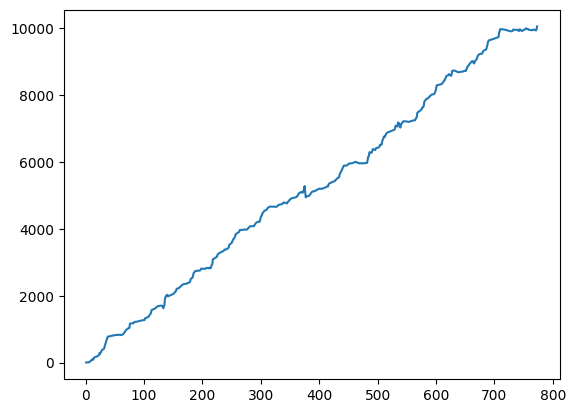

In [43]:
date_portfolio[ (date_portfolio.Count == 1) ].PL.cumsum().plot()
# date_portfolio[ (date_portfolio.topReturnlast_10D.rolling(window=100,min_periods=1).rank(ascending=True, pct=True) )<0.05 ].PL.cumsum().plot()

<Axes: >

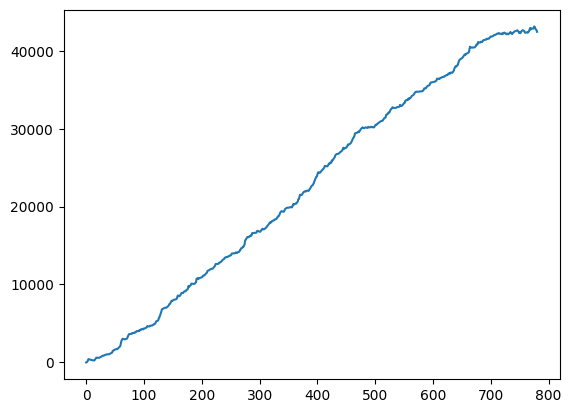

In [44]:
date_portfolio[ date_portfolio.Count == 0 ].PL.cumsum().plot()

In [ ]:
abonraml_DATE = date_portfolio[ (date_portfolio.Count ==1) ].Date.to_list()

In [70]:
abonraml_DATE

['20230110',
 '20230117',
 '20230131',
 '20230203',
 '20230206',
 '20230207',
 '20230209',
 '20230215',
 '20230216',
 '20230217',
 '20230221',
 '20230222',
 '20230223',
 '20230301',
 '20230302',
 '20230307',
 '20230308',
 '20230310',
 '20230313',
 '20230314',
 '20230316',
 '20230323',
 '20230406',
 '20230417',
 '20230424',
 '20230426',
 '20230427',
 '20230503',
 '20230504',
 '20230510',
 '20230512',
 '20230515',
 '20230517',
 '20230523',
 '20230524',
 '20230601',
 '20230614',
 '20230619',
 '20230620',
 '20230626',
 '20230630',
 '20230706',
 '20230707',
 '20230717',
 '20230721',
 '20230728',
 '20230804',
 '20230807',
 '20230809',
 '20230810',
 '20230814',
 '20230816',
 '20230817',
 '20230825',
 '20230831',
 '20230904',
 '20230905',
 '20230907',
 '20230913',
 '20230918',
 '20230921',
 '20230922',
 '20230927',
 '20231004',
 '20231013',
 '20231016',
 '20231019',
 '20231020',
 '20231023',
 '20231026',
 '20231107',
 '20231109',
 '20231120',
 '20231122',
 '20231128',
 '20231129',
 '20231201',

import json

# 假設這是你的異常日期清單 (字串格式)

# 將 list 存成 JSON 檔案
with open('abnormal_dates.json', 'w') as f:
    json.dump(abonraml_DATE, f)
    
print("異常日期清單已儲存！")

In [47]:
condition = date_portfolio.test > -0.005
print(condition.sum())
date_portfolio[ condition ].PL.cumsum().plot()

AttributeError: 'DataFrame' object has no attribute 'test'